# 11 · Model Evaluation — Where Both Courses Meet

**Session 15 · Sat Oct 17 · final session**

This notebook closes the loop. You will build a real classifier, discover that its headline accuracy
is a lie, and then watch the fairness impossibility result appear out of pure arithmetic — not as
philosophy, but as a constraint you can compute.

By the end you will have written, in code, the central technical argument of PhDAI 832.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd().parent / "data"
rng = np.random.default_rng(42)   # same seed => same numbers every time you run this

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)

lending = pd.read_csv(DATA / "lending.csv")
print(f"{len(lending):,} loans, {lending.defaulted.mean():.2%} defaulted")

4,000 loans, 9.20% defaulted


## 1 · Train/test split — why you never score on training data

A model can memorise the data it was fitted on. The only honest test is data it has never seen.

In [3]:
FEATURES = ["annual_income", "credit_score", "employment_years", "dti_ratio", "loan_amount"]
X = lending[FEATURES]
y = lending["defaulted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)   # stratify keeps the 9% rate in both

print(f"train: {len(X_train):,} rows, {y_train.mean():.2%} default")
print(f"test:  {len(X_test):,} rows, {y_test.mean():.2%} default")

train: 2,800 rows, 9.21% default
test:  1,200 rows, 9.17% default


## 2 · Logistic regression

Linear regression predicts a number. For a yes/no outcome you need a probability between 0 and 1, so
logistic regression passes the linear part through a squashing function.

/Users/ronaldnefiross/PhD/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/ronaldnefiross/PhD/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


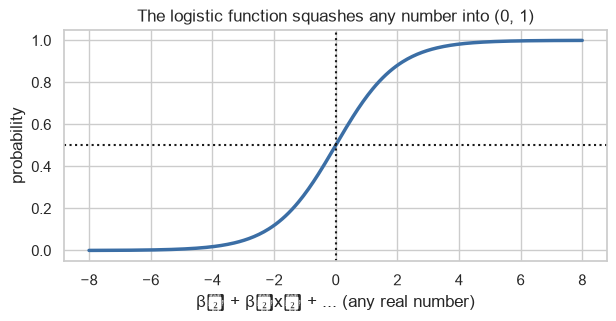

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
z = np.linspace(-8, 8, 300)
ax.plot(z, 1/(1+np.exp(-z)), lw=2.5, color="#3b6ea5")
ax.axhline(.5, ls=":", color="k"); ax.axvline(0, ls=":", color="k")
ax.set_title("The logistic function squashes any number into (0, 1)")
ax.set_xlabel("β₀ + β₁x₁ + ... (any real number)"); ax.set_ylabel("probability")
plt.show()

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]      # P(default) for each test loan
preds = (probs >= 0.5).astype(int)             # the DEFAULT threshold, 0.5

print("model trained. first 5 predicted probabilities:")
print(np.round(probs[:5], 4))

model trained. first 5 predicted probabilities:
[0.1396 0.0499 0.0452 0.0715 0.124 ]


## 3 · The accuracy trap

Here is the headline number a vendor would put on a slide.

In [6]:
print(f"ACCURACY: {accuracy_score(y_test, preds):.2%}")
print()
print("...now compare it to a model that does no work whatsoever:")
print(f"'nobody ever defaults':  {accuracy_score(y_test, np.zeros(len(y_test))):.2%}")

ACCURACY: 90.83%

...now compare it to a model that does no work whatsoever:
'nobody ever defaults':  90.83%


### Read those two numbers together

They are **the same number**. 90.83% either way.

The model has not merely underperformed — at a 0.5 threshold it has collapsed into the constant
"nobody defaults," and its accuracy is exactly that of a rule that ignores every input you gave it.
Look at *why*:

In [7]:
cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()

print("                 predicted no   predicted yes")
print(f"actually no      {tn:>12,}   {fp:>13,}")
print(f"actually yes     {fn:>12,}   {tp:>13,}")
print()
print(f"of {tp+fn} real defaults in the test set, the model caught {tp}")
print(f"RECALL = {recall_score(y_test, preds):.1%}")
print()
print("Look at the predicted-yes column: it is EMPTY. At a 0.5 threshold this model")
print("predicts 'no default' for every single loan in the test set. It catches none of")
print("the 110 real defaults, and its accuracy is IDENTICAL to the do-nothing baseline.")
print("For a bank it is worthless -- the entire business value is catching defaults.")

                 predicted no   predicted yes
actually no             1,090               0
actually yes              110               0

of 110 real defaults in the test set, the model caught 0
RECALL = 0.0%

Look at the predicted-yes column: it is EMPTY. At a 0.5 threshold this model
predicts 'no default' for every single loan in the test set. It catches none of
the 110 real defaults, and its accuracy is IDENTICAL to the do-nothing baseline.
For a bank it is worthless -- the entire business value is catching defaults.


**This is the single most important practical lesson in model evaluation.** On imbalanced data,
accuracy measures how common the majority class is, not how good your model is. You will hear
"our model is 91% accurate" for the rest of your career. The correct reply is *"what is the base
rate, and what is the recall?"*

## 4 · The threshold is a policy decision, not a technical default

0.5 is a convention, not a law. Moving it trades false alarms against missed defaults — and that
trade-off is a business and ethical choice, not something the model can decide for you.

In [8]:
rows = []
for th in [0.05, 0.09, 0.15, 0.25, 0.5, 0.75]:
    p = (probs >= th).astype(int)
    if p.sum() == 0:
        continue
    rows.append({
        "threshold": th,
        "flagged":   p.sum(),
        "precision": f"{precision_score(y_test, p, zero_division=0):.1%}",
        "recall":    f"{recall_score(y_test, p):.1%}",
        "accuracy":  f"{accuracy_score(y_test, p):.1%}",
    })
print(pd.DataFrame(rows).to_string(index=False))
print()
print("Lower threshold -> catch more defaults, raise more false alarms.")
print("There is no 'correct' row here. The right choice depends on what a missed")
print("default costs you versus what wrongly denying a good applicant costs THEM.")
print("That second cost is not in your data, and no metric will supply it.")

 threshold  flagged precision recall accuracy
      0.05      902     11.9%  97.3%    33.5%
      0.09      513     17.2%  80.0%    62.7%
      0.15      178     27.0%  43.6%    84.0%
      0.25       25     40.0%   9.1%    90.4%

Lower threshold -> catch more defaults, raise more false alarms.
There is no 'correct' row here. The right choice depends on what a missed
default costs you versus what wrongly denying a good applicant costs THEM.
That second cost is not in your data, and no metric will supply it.


## 5 · ROC and AUC — performance independent of threshold

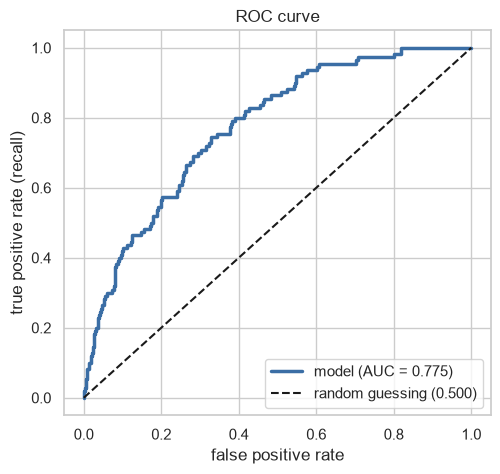

AUC = 0.775

Interpretation: pick one random defaulter and one random non-defaulter.
AUC is the probability the model scores the defaulter higher -- 77.5% here.
AUC judges the RANKING, so it is threshold-free. Note how much more useful
it is than the 90.8% accuracy figure.


In [9]:
fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, lw=2.5, color="#3b6ea5", label=f"model (AUC = {auc:.3f})")
ax.plot([0,1], [0,1], ls="--", color="k", label="random guessing (0.500)")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate (recall)")
ax.set_title("ROC curve"); ax.legend(loc="lower right"); plt.show()

print(f"AUC = {auc:.3f}")
print("\nInterpretation: pick one random defaulter and one random non-defaulter.")
print(f"AUC is the probability the model scores the defaulter higher -- {auc:.1%} here.")
print("AUC judges the RANKING, so it is threshold-free. Note how much more useful")
print(f"it is than the {accuracy_score(y_test, preds):.1%} accuracy figure.")

## 6 · The fairness impossibility result, computed

Now the part that matters for PhDAI 832. Let's evaluate the same model separately by group.

Recall from `make_data.py` that **`applicant_group` was never given to the model** — it is not in
`FEATURES`. The model is "blind" to group in the naive sense.

In [10]:
test = lending.loc[X_test.index].copy()
test["prob"] = probs
test["pred"] = preds

print("FEATURES given to the model:", FEATURES)
print("'applicant_group' included:", "applicant_group" in FEATURES)
print()

rows = []
for g, d in test.groupby("applicant_group"):
    p = (d.prob >= 0.5).astype(int)
    rows.append({
        "group": g, "n": len(d),
        "base rate":    f"{d.defaulted.mean():.1%}",
        "mean P(def)":  f"{d.prob.mean():.3f}",
        "flag rate":    f"{(d.prob >= 0.15).mean():.1%}",
        "recall@0.15":  f"{recall_score(d.defaulted, (d.prob>=0.15).astype(int), zero_division=0):.1%}",
        "FPR@0.15":     f"{((d.prob>=0.15) & (d.defaulted==0)).sum() / max((d.defaulted==0).sum(),1):.1%}",
    })
print(pd.DataFrame(rows).to_string(index=False))

FEATURES given to the model: ['annual_income', 'credit_score', 'employment_years', 'dti_ratio', 'loan_amount']
'applicant_group' included: False

group   n base rate mean P(def) flag rate recall@0.15 FPR@0.15
    A 854      7.1%       0.086     11.6%       36.1%     9.7%
    B 346     14.2%       0.110     22.8%       53.1%    17.8%


### Group membership was never an input, and the outcomes still differ

This is **historical bias**, and it is the single most misunderstood point in applied AI ethics.
Deleting the protected attribute does not produce a fair model, because the remaining features
(income, credit score) carry the disparity. The model learns the pattern through its proxies.

"We don't use race/gender in the model" is therefore not a fairness argument. It is barely relevant.

### Now the impossibility

Three reasonable definitions of fairness:

1. **Demographic parity** — flag the same *proportion* of each group.
2. **Equal opportunity** — equal *recall* in each group (catch the same share of true defaulters).
3. **Calibration** — a score of 0.3 means a 30% real default rate in *every* group.

Let's try to satisfy the first two at once by tuning a separate threshold per group.

In [11]:
A = test[test.applicant_group == "A"]
B = test[test.applicant_group == "B"]

def at(d, th):
    p = (d.prob >= th).astype(int)
    neg = (d.defaulted == 0).sum()
    return {"flag": p.mean(),
            "recall": recall_score(d.defaulted, p, zero_division=0),
            "fpr": ((p == 1) & (d.defaulted == 0)).sum() / max(neg, 1)}

grid = np.linspace(0.02, 0.60, 300)

target = at(A, 0.15)
print(f"Group A at threshold 0.15 -> flag rate {target['flag']:.1%}, recall {target['recall']:.1%}")
print()

th_parity  = grid[np.argmin([abs(at(B, t)["flag"]   - target["flag"])   for t in grid])]
th_equalop = grid[np.argmin([abs(at(B, t)["recall"] - target["recall"]) for t in grid])]

b_par, b_eq = at(B, th_parity), at(B, th_equalop)

print(f"To give group B the SAME FLAG RATE  -> threshold {th_parity:.3f}")
print(f"   B's recall becomes {b_par['recall']:.1%}  vs A's {target['recall']:.1%}   <-- UNEQUAL")
print()
print(f"To give group B the SAME RECALL     -> threshold {th_equalop:.3f}")
print(f"   B's flag rate becomes {b_eq['flag']:.1%}  vs A's {target['flag']:.1%}   <-- UNEQUAL")
print()
print("Now look past the thresholds at what this does to actual people:")
print()
print(f"  Equalising RECALL  -> group B is flagged at {b_eq['flag']/target['flag']:.2f}x")
print(f"                        group A's rate ({b_eq['flag']:.1%} vs {target['flag']:.1%}).")
print(f"                        More of B's good applicants are wrongly caught.")
print()
print(f"  Equalising FLAGS   -> only {b_par['recall']:.1%} of B's genuine defaulters are")
print(f"                        caught, against {target['recall']:.1%} of A's.")
print(f"                        The bank absorbs more unflagged risk from group B.")
print()
print("Both are defensible. They are not simultaneously achievable. You must CHOOSE,")
print("and the choice decides who bears the cost of the model being wrong.")

Group A at threshold 0.15 -> flag rate 11.6%, recall 36.1%



To give group B the SAME FLAG RATE  -> threshold 0.183
   B's recall becomes 32.7%  vs A's 36.1%   <-- UNEQUAL

To give group B the SAME RECALL     -> threshold 0.171
   B's flag rate becomes 16.8%  vs A's 11.6%   <-- UNEQUAL

Now look past the thresholds at what this does to actual people:

  Equalising RECALL  -> group B is flagged at 1.45x
                        group A's rate (16.8% vs 11.6%).
                        More of B's good applicants are wrongly caught.

  Equalising FLAGS   -> only 32.7% of B's genuine defaulters are
                        caught, against 36.1% of A's.
                        The bank absorbs more unflagged risk from group B.

Both are defensible. They are not simultaneously achievable. You must CHOOSE,
and the choice decides who bears the cost of the model being wrong.


### That is the impossibility result

You cannot satisfy both. Not because the code is inadequate or the model is badly built, but because
**the groups have different base rates** (12.6% vs 7.9%), and the arithmetic of a confusion matrix
does not permit equalising flag rates and recall simultaneously when base rates differ.

This is the formal result of Kleinberg, Mullainathan & Raghavan (2016) and Chouldechova (2017):
*calibration, equal false-positive rates, and equal false-negative rates cannot all hold at once
unless base rates are equal or the classifier is perfect.*

**What that means for you as a practitioner.** "Make the model fair" is not a well-posed engineering
request. Somebody has to decide *which* fairness definition governs, and that decision:

- is **normative**, not technical — it cannot be derived from the data;
- has identifiable winners and losers under each choice;
- belongs to governance, with an auditable record of the reasoning.

Which is exactly the argument your SR 11-7 experience equips you to make. Model risk management
already demands documented rationale for model choices, an independent challenge function, and
ongoing monitoring. That is the governance machinery the NIST AI RMF asks for under **Govern** and
**Manage** — you have been operating it for years, and most of your cohort has not.

In [12]:
# The base rates that make it impossible:
print(test.groupby("applicant_group").agg(
    n=("defaulted","size"), base_rate=("defaulted","mean")).assign(
    base_rate=lambda d: (d.base_rate*100).round(2).astype(str) + "%"))
print("\nDifferent base rates => the impossibility binds. This is arithmetic, not ideology.")

                   n base_rate
applicant_group               
A                854     7.14%
B                346    14.16%

Different base rates => the impossibility binds. This is arithmetic, not ideology.


## Your turn

**Exercise 1.** Find the threshold that maximises the F1 score on the test set. How does it compare
to 0.5, and what does that tell you about the default?

In [13]:
# your code here

In [ ]:
from sklearn.metrics import f1_score
grid = np.linspace(0.02, 0.9, 400)
f1s = [f1_score(y_test, (probs>=t).astype(int), zero_division=0) for t in grid]
best = grid[int(np.argmax(f1s))]

fig, ax = plt.subplots(figsize=(8,3.2))
ax.plot(grid, f1s, color="#3b6ea5"); ax.axvline(best, color="#a5533b", ls="--",
        label=f"best {best:.3f}"); ax.axvline(0.5, color="k", ls=":", label="default 0.5")
ax.set_xlabel("threshold"); ax.set_ylabel("F1"); ax.legend(); plt.show()

print(f"best threshold {best:.3f} (F1 {max(f1s):.3f}) vs 0.5 (F1 "
      f"{f1_score(y_test,(probs>=0.5).astype(int), zero_division=0):.3f})")
# Far below 0.5. On imbalanced data the 0.5 default is almost always wrong --
# it is an artefact of the library, not a considered choice.

**Exercise 2.** Compute **calibration** by group: bucket predicted probabilities and compare the
predicted rate to the actual default rate within each group. Is the model calibrated?

In [15]:
# your code here

In [ ]:
t = test.copy()
t["bucket"] = pd.cut(t.prob, [0,.05,.1,.15,.25,1.0])
cal = t.groupby(["applicant_group","bucket"], observed=True).agg(
    n=("defaulted","size"), predicted=("prob","mean"), actual=("defaulted","mean")).round(3)
print(cal)

fig, ax = plt.subplots(figsize=(6,5))
for g, d in cal.reset_index().groupby("applicant_group"):
    ax.plot(d.predicted, d.actual, "o-", label=f"group {g}")
ax.plot([0,.4],[0,.4], "k--", label="perfect calibration")
ax.set_xlabel("mean predicted P(default)"); ax.set_ylabel("actual default rate")
ax.legend(); plt.show()

# Both groups track the diagonal reasonably -- the model is roughly calibrated for BOTH.
# And that is precisely the trap: a calibrated model still produces unequal flag rates
# and unequal recall, because the base rates differ. Calibration is a real fairness
# property, and satisfying it FORECLOSES the other two. That is the impossibility,
# seen from the third side.

## What you did today — and what you carry into the term

- Train/test split, logistic regression, and a probability you can threshold.
- **The accuracy trap**: 91% accuracy from a model that catches almost no defaults.
- Precision/recall/ROC/AUC, and the threshold as a **policy** lever rather than a default.
- Proved that removing the protected attribute does **not** remove disparity — proxies carry it.
- **Computed the fairness impossibility result** and connected it to SR 11-7 governance.

### You are ready

Across eleven notebooks you have: loaded and described data, met the distributions, derived Bayes by
counting, watched the CLT appear, built a p-value from scratch, bootstrapped a fairness metric,
fitted and criticised regressions, and evaluated a classifier across groups.

That is the working content of PhDAI 730, and the technical spine of PhDAI 832. Go back through
`00-notation-cheatsheet.md` once more before Oct 19, and keep it open during your first lectures.